In [29]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

In [30]:
def dilation_manual(img, kernel_size=3):
    height, width = img.shape
    pad = kernel_size // 2
    padded = np.pad(img, pad, mode='constant', constant_values=0)
    canvas = np.zeros_like(img, dtype=np.uint8)
    for i in range(height):
        for j in range(width):
            region = padded[i:i+kernel_size, j:j+kernel_size]
            if np.max(region) == 255:
                canvas[i, j] = 255
    return canvas

def erosion_manual(img, kernel_size=3):
    height, width = img.shape
    pad = kernel_size // 2
    padded = np.pad(img, pad, mode='constant', constant_values=0)
    canvas = np.zeros_like(img, dtype=np.uint8)
    for i in range(height):
        for j in range(width):
            region = padded[i:i+kernel_size, j:j+kernel_size]
            if np.min(region) == 255:
                canvas[i, j] = 255
    return canvas

def filter(img, size, mode):
    height, width = img.shape
    pad = size // 2
    padded = np.pad(img, pad, mode='edge')
    canvas = np.zeros_like(img, dtype=np.uint8)
    
    match mode:
        case 'mean':
            area = size * size
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    canvas[i, j] = np.sum(region) // area
                    
        case 'median':
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    region_flat = np.sort(region.ravel())
                    canvas[i, j] = region_flat[(size * size) // 2]
                    
        case 'modus':
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    values = region.ravel()
                    count = {}
                    for val in values:
                        if val in count:
                            count[val] += 1
                        else:
                            count[val] = 1
                            
                    max_count = 0
                    mode_val = 0
                    for val, freq in count.items():
                        if freq > max_count:
                            max_count = freq
                            mode_val = val
                            
                    canvas[i, j] = mode_val
                    
    return canvas

def gradient_morph(img, kernel_size=3):
    img_uint8 = img.astype(np.uint8)
    _, img_binary = cv2.threshold(img_uint8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    hasil_dilasi = dilation_manual(img_binary, kernel_size).astype(np.float32)
    hasil_erosi  = erosion_manual(img_binary, kernel_size).astype(np.float32)
    gradien = hasil_dilasi - hasil_erosi
    return np.clip(gradien, 0, 255).astype(np.uint8)

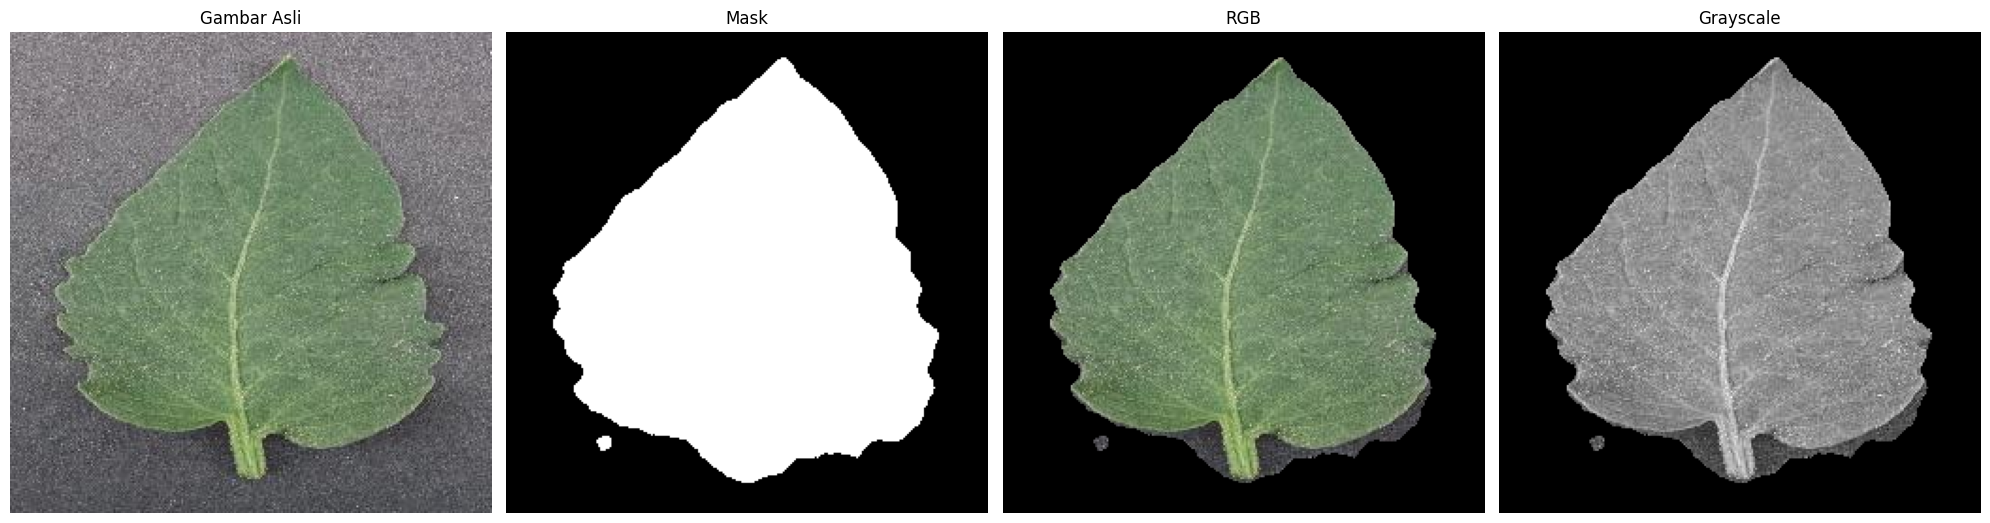

In [31]:
daun_bgr = cv2.imread('archive/tomato/healty.JPG')
daun_rgb = cv2.cvtColor(daun_bgr, cv2.COLOR_BGR2RGB)

tinggi, lebar = daun_rgb.shape[:2]
mask_raw = np.zeros((tinggi, lebar), dtype=np.uint8)

for i in range(tinggi):
    for j in range(lebar):
        r = int(daun_rgb[i, j, 0])
        g = int(daun_rgb[i, j, 1])
        b = int(daun_rgb[i, j, 2])
        total_rgb = r + g + b
        if (g > b + 15) or (r > b + 15) or (total_rgb < 200):
            mask_raw[i, j] = 255
        else:
            mask_raw[i, j] = 0

mask_dilated = dilation_manual(mask_raw, kernel_size=3)
mask_eroded = erosion_manual(mask_dilated, kernel_size=3)
mask_fg_final = filter(mask_eroded, 9, 'median')

daun_removed = np.zeros((tinggi, lebar, 3), dtype=np.uint8)

for i in range(tinggi):
    for j in range(lebar):
        if mask_fg_final[i, j] == 255:
            daun_removed[i, j, 0] = daun_rgb[i, j, 0]
            daun_removed[i, j, 1] = daun_rgb[i, j, 1]
            daun_removed[i, j, 2] = daun_rgb[i, j, 2]
        else:
            daun_removed[i, j, 0] = 0
            daun_removed[i, j, 1] = 0
            daun_removed[i, j, 2] = 0

daun_akhir_gray = cv2.cvtColor(daun_removed, cv2.COLOR_RGB2GRAY)

plt.figure(figsize=(20, 6))

plt.subplot(1, 4, 1)
plt.imshow(daun_rgb)
plt.title('Gambar Asli')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(mask_fg_final, cmap='gray')
plt.title('Mask')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(daun_removed)
plt.title('RGB')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(daun_akhir_gray, cmap='gray')
plt.title('Grayscale')
plt.axis('off')

plt.tight_layout()
plt.show()

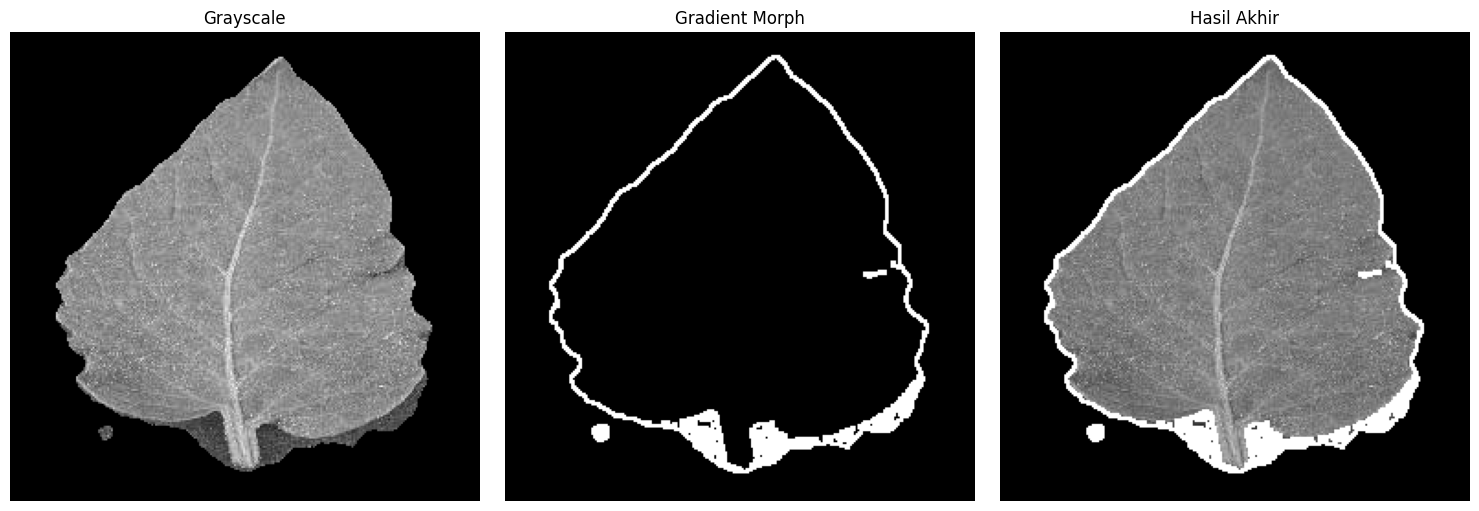

In [32]:
grad = gradient_morph(daun_akhir_gray)
hasil_akhir = np.clip(daun_akhir_gray.astype(np.int32) + grad.astype(np.int32), 0, 255).astype(np.uint8)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(daun_akhir_gray, cmap='gray')
plt.title('Grayscale')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(grad, cmap='gray')
plt.title('Gradient Morph')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(hasil_akhir, cmap='gray')
plt.title('Hasil Akhir')
plt.axis('off')

plt.tight_layout()
plt.show()

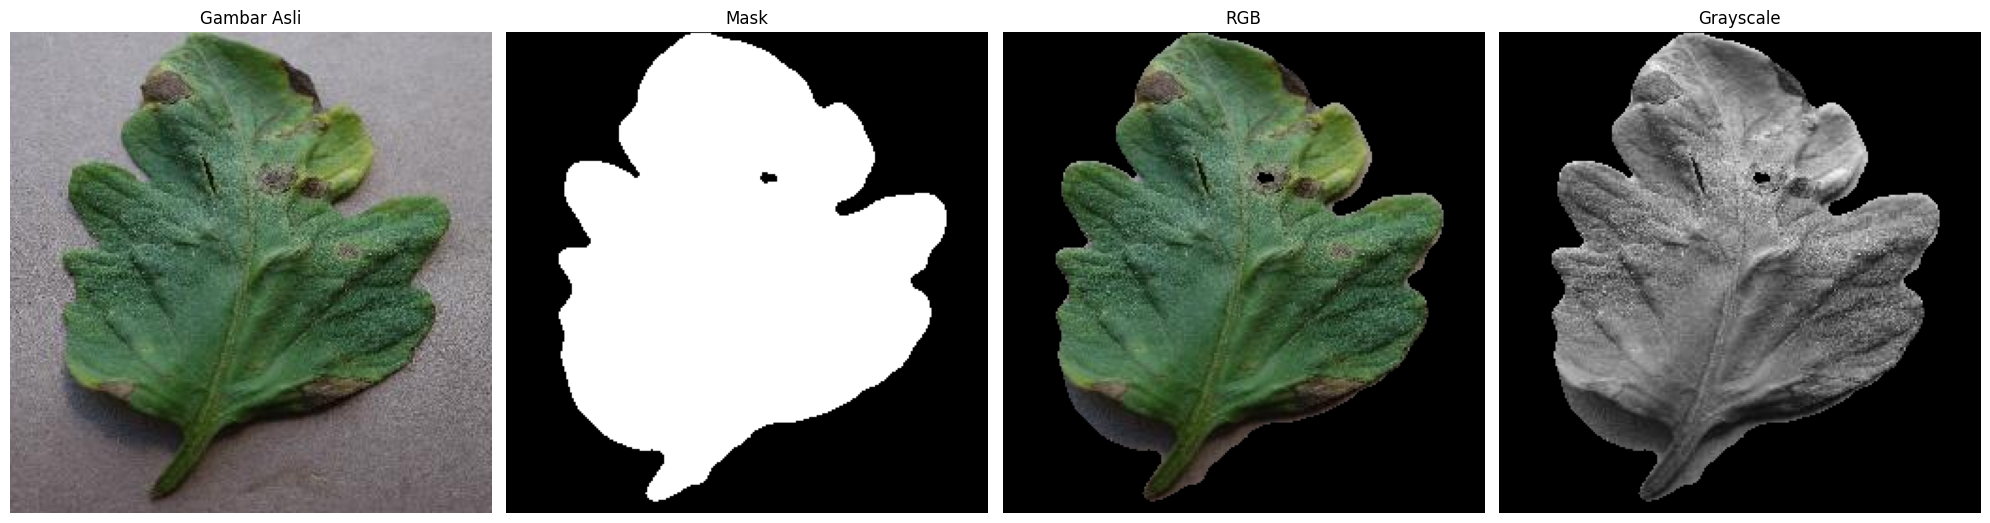

In [33]:
daun_bgr = cv2.imread('archive/tomato/early.JPG')
daun_rgb = cv2.cvtColor(daun_bgr, cv2.COLOR_BGR2RGB)

tinggi, lebar = daun_rgb.shape[:2]
mask_raw = np.zeros((tinggi, lebar), dtype=np.uint8)

for i in range(tinggi):
    for j in range(lebar):
        r = int(daun_rgb[i, j, 0])
        g = int(daun_rgb[i, j, 1])
        b = int(daun_rgb[i, j, 2])
        total_rgb = r + g + b
        if (g > b + 15) or (r > b + 15) or (total_rgb < 200):
            mask_raw[i, j] = 255
        else:
            mask_raw[i, j] = 0

mask_dilated = dilation_manual(mask_raw, kernel_size=3)
mask_eroded = erosion_manual(mask_dilated, kernel_size=3)
mask_fg_final = filter(mask_eroded, 9, 'median')

daun_removed = np.zeros((tinggi, lebar, 3), dtype=np.uint8)

for i in range(tinggi):
    for j in range(lebar):
        if mask_fg_final[i, j] == 255:
            daun_removed[i, j, 0] = daun_rgb[i, j, 0]
            daun_removed[i, j, 1] = daun_rgb[i, j, 1]
            daun_removed[i, j, 2] = daun_rgb[i, j, 2]
        else:
            daun_removed[i, j, 0] = 0
            daun_removed[i, j, 1] = 0
            daun_removed[i, j, 2] = 0

daun_akhir_gray = cv2.cvtColor(daun_removed, cv2.COLOR_RGB2GRAY)

plt.figure(figsize=(20, 6))

plt.subplot(1, 4, 1)
plt.imshow(daun_rgb)
plt.title('Gambar Asli')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(mask_fg_final, cmap='gray')
plt.title('Mask')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(daun_removed)
plt.title('RGB')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(daun_akhir_gray, cmap='gray')
plt.title('Grayscale')
plt.axis('off')

plt.tight_layout()
plt.show()

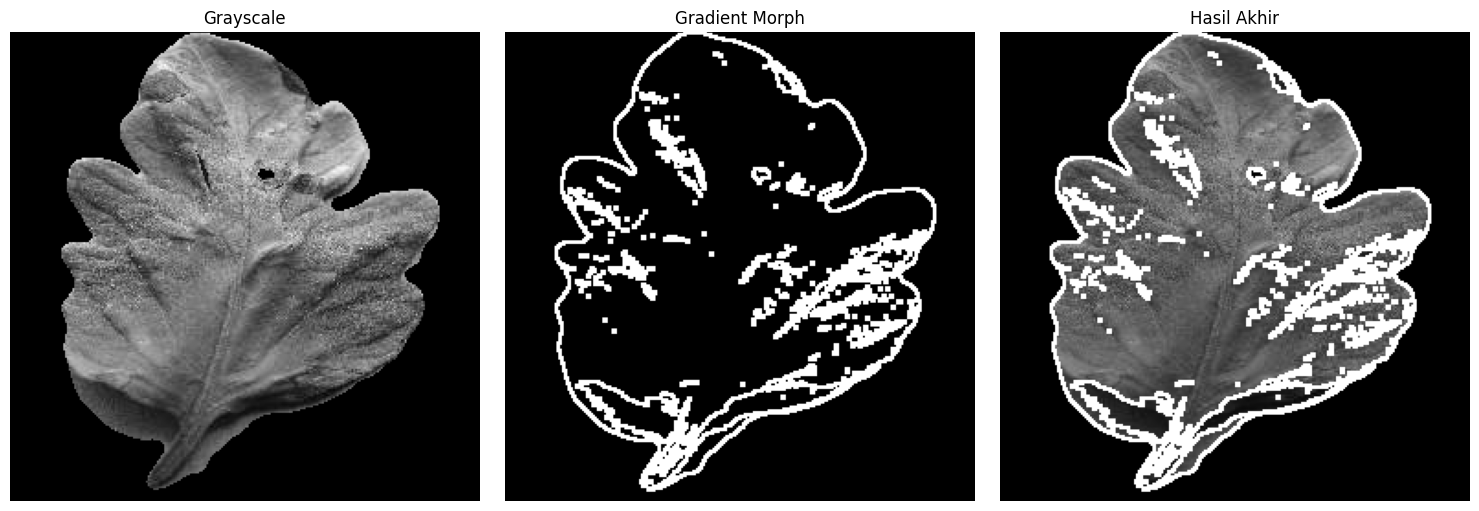

In [34]:
grad = gradient_morph(daun_akhir_gray)
hasil_akhir = np.clip(daun_akhir_gray.astype(np.int32) + grad.astype(np.int32), 0, 255).astype(np.uint8)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(daun_akhir_gray, cmap='gray')
plt.title('Grayscale')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(grad, cmap='gray')
plt.title('Gradient Morph')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(hasil_akhir, cmap='gray')
plt.title('Hasil Akhir')
plt.axis('off')

plt.tight_layout()
plt.show()

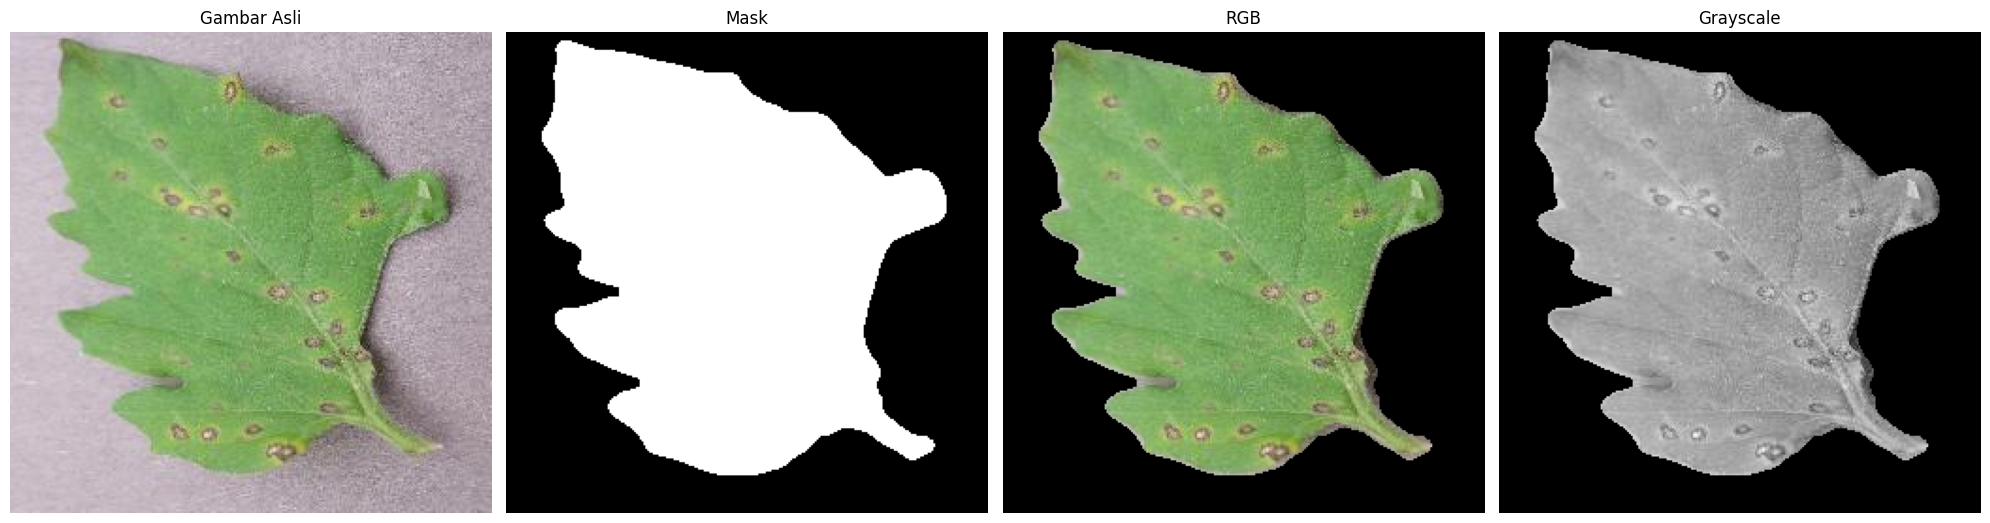

In [35]:
daun_bgr = cv2.imread('archive/tomato/septoria.JPG')
daun_rgb = cv2.cvtColor(daun_bgr, cv2.COLOR_BGR2RGB)

tinggi, lebar = daun_rgb.shape[:2]
mask_raw = np.zeros((tinggi, lebar), dtype=np.uint8)

for i in range(tinggi):
    for j in range(lebar):
        r = int(daun_rgb[i, j, 0])
        g = int(daun_rgb[i, j, 1])
        b = int(daun_rgb[i, j, 2])
        total_rgb = r + g + b
        if (g > b + 15) or (r > b + 15) or (total_rgb < 200):
            mask_raw[i, j] = 255
        else:
            mask_raw[i, j] = 0

mask_dilated = dilation_manual(mask_raw, kernel_size=3)
mask_eroded = erosion_manual(mask_dilated, kernel_size=3)
mask_fg_final = filter(mask_eroded, 9, 'median')

daun_removed = np.zeros((tinggi, lebar, 3), dtype=np.uint8)

for i in range(tinggi):
    for j in range(lebar):
        if mask_fg_final[i, j] == 255:
            daun_removed[i, j, 0] = daun_rgb[i, j, 0]
            daun_removed[i, j, 1] = daun_rgb[i, j, 1]
            daun_removed[i, j, 2] = daun_rgb[i, j, 2]
        else:
            daun_removed[i, j, 0] = 0
            daun_removed[i, j, 1] = 0
            daun_removed[i, j, 2] = 0

daun_akhir_gray = cv2.cvtColor(daun_removed, cv2.COLOR_RGB2GRAY)

plt.figure(figsize=(20, 6))

plt.subplot(1, 4, 1)
plt.imshow(daun_rgb)
plt.title('Gambar Asli')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(mask_fg_final, cmap='gray')
plt.title('Mask')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(daun_removed)
plt.title('RGB')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(daun_akhir_gray, cmap='gray')
plt.title('Grayscale')
plt.axis('off')

plt.tight_layout()
plt.show()

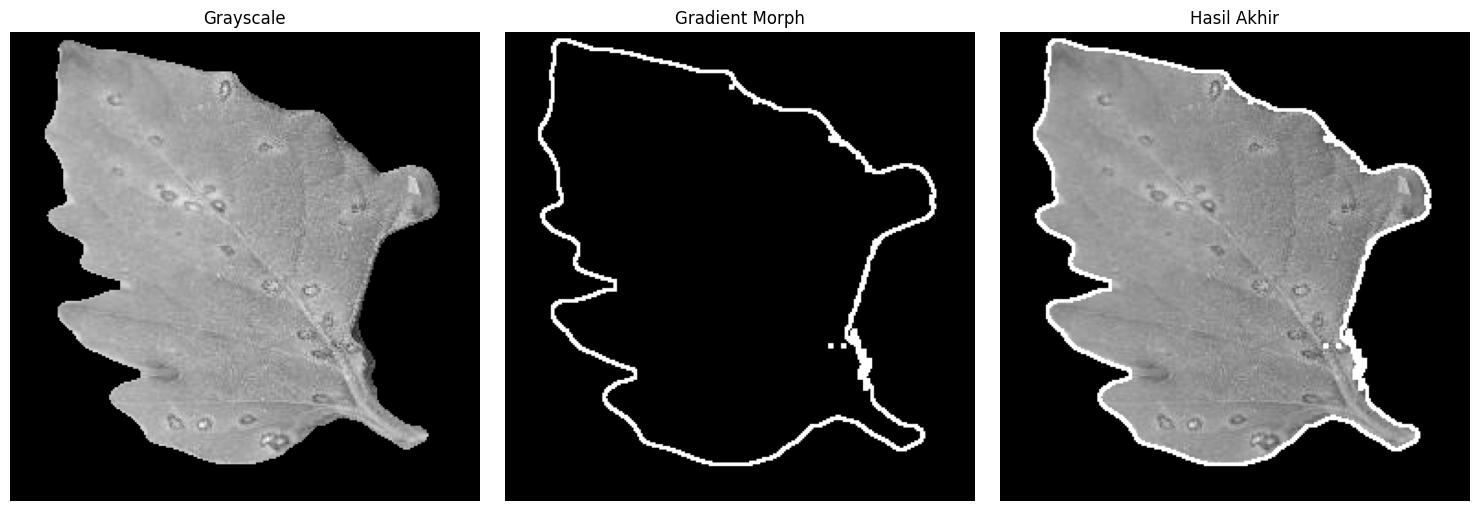

In [36]:
grad = gradient_morph(daun_akhir_gray)
hasil_akhir = np.clip(daun_akhir_gray.astype(np.int32) + grad.astype(np.int32), 0, 255).astype(np.uint8)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(daun_akhir_gray, cmap='gray')
plt.title('Grayscale')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(grad, cmap='gray')
plt.title('Gradient Morph')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(hasil_akhir, cmap='gray')
plt.title('Hasil Akhir')
plt.axis('off')

plt.tight_layout()
plt.show()